In [1]:
import json
import subprocess
import pandas as pd
import tempfile
import os
from pathlib import Path

#====================================================================
# 📂 Define Input Parameters
#====================================================================
CALIB_DIR = Path("../data/inferno")
RSCRIPT_PATH = Path("../RScripts/inferno2py.R")
df = pd.read_csv(CALIB_DIR / "calibration_test.csv")
index = 1050
row = df.iloc[index]

config = {
    "input_csv": str(CALIB_DIR / "calibration_test.csv"),
    "model_path": str(CALIB_DIR / "effusion" / "learnt.rds"),
    "row_index": int(index),
    "quantiles": [float(q) for q in [0.055, 0.25, 0.75, 0.945]],
    "input_values": {
        "LOGIT_EFFUSION": [float(row.LOGIT_EFFUSION)],
        "AGE": [float(row.AGE)],
        "GENDER": [row.GENDER],
        "VP": [row.VP]
    }
}

#====================================================================
# 🔍 Write Config to Temporary JSON File
#====================================================================
with tempfile.NamedTemporaryFile(delete=False, suffix=".json", mode="w") as temp_config_file:
    json.dump(config, temp_config_file, indent=2)
    temp_config_path = temp_config_file.name

#====================================================================
# 🔄 Run R Script Using Config
#====================================================================
subprocess.run(["Rscript", str(RSCRIPT_PATH), temp_config_path], check=True)

#====================================================================
# 📂 Load Result from R Output
#====================================================================
result_path = os.path.join(os.path.dirname(config["input_csv"]), "result_probs.json")
with open(result_path, "r") as f:
    result = json.load(f)

# Convert to DataFrame if needed
values_df = pd.DataFrame(result["values"])
print(values_df)

# Clean up temporary config file
os.remove(temp_config_path)

                                                                  IMGPATH
1050 /home/maxvill/InfernoCalibNet/data/raw/xrays/xrays5/00002909_003.png
       DISEASELABEL MULTIHOT FOLLOWUP PATID AGE GENDER VP LOGIT_EFFUSION
1050 ['No Finding']   [0, 0]        3  2909  61      F PA     -0.5445151
     LABEL_EFFUSION LOGIT_ATELECTASIS LABEL_ATELECTASIS
1050              0         -1.101741                 0
        0
0  0.8249
1  0.1751


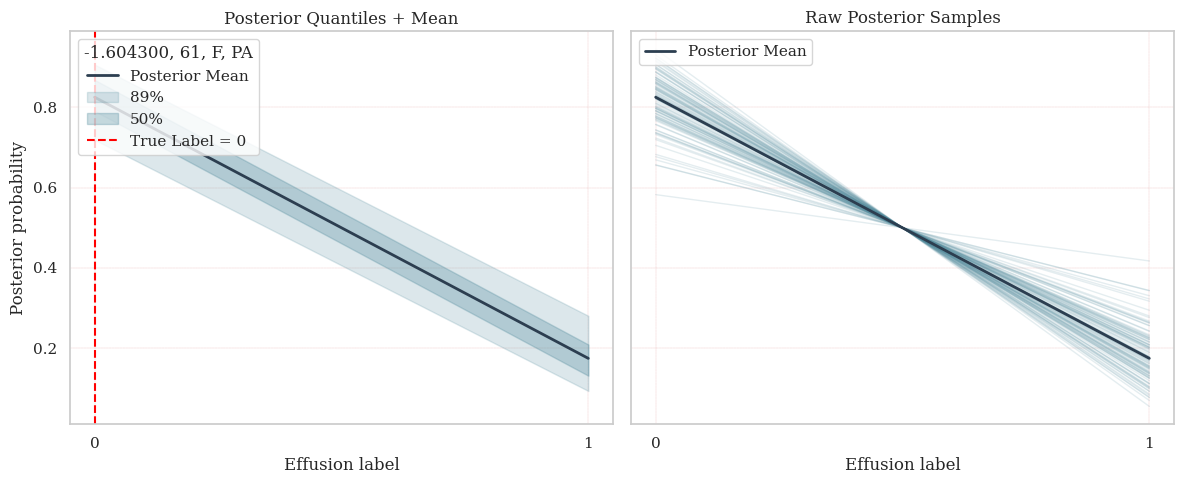

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# Set seaborn theme
sns.set_theme(
    context='notebook',
    style='whitegrid',
    palette=sns.diverging_palette(220, 20, n=2),
    font='serif',
    font_scale=1,
    color_codes=True,
    rc=None
)

# Customize grid appearance
plt.rcParams['axes.grid'] = True
plt.rc('grid', linestyle='--', linewidth=0.1, color="#c82727")

# Load Inferno result JSON
with open('../data/inferno/result_probs.json', 'r') as f:
    data = json.load(f)

x = [0, 1]
samples = np.array([s[0] for s in data['samples']])
quantiles = [q[0] for q in data['quantiles']]
means = [v[0] for v in data['values']]
true_label = data['true_label']
lines = np.stack(samples, axis=1)

meta = data["X"][0]
title = f"{meta['LOGIT_EFFUSION']:.6f}, {meta['AGE']}, {meta['GENDER']}, {meta['VP']}"

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left subplot: Quantiles + Mean
axs[0].plot(x, means, color="#2c3e50", linewidth=2, label="Posterior Mean")

q_lower = [q[0] for q in quantiles]
q_upper = [q[3] for q in quantiles]
axs[0].fill_between(x, q_lower, q_upper, color="#508a9c", alpha=0.2, label="89%")

q_lower2 = [q[1] for q in quantiles]
q_upper2 = [q[2] for q in quantiles]
axs[0].fill_between(x, q_lower2, q_upper2, color="#508a9c", alpha=0.3, label="50%")

axs[0].axvline(true_label, linestyle="--", color="red", label=f"True Label = {true_label}")
axs[0].legend(title=title, loc="upper left")
axs[0].set_xticks(x)
axs[0].set_xlabel("Effusion label")
axs[0].set_ylabel("Posterior probability")
axs[0].set_title("Posterior Quantiles + Mean")
axs[0].grid(True)

# Right subplot: Raw samples + Mean
for row in lines:
    axs[1].plot(x, row, color="#508a9c", alpha=0.15, linewidth=1)

axs[1].plot(x, means, color="#2c3e50", linewidth=2, label="Posterior Mean")
axs[1].legend(loc="upper left")
axs[1].set_xticks(x)
axs[1].set_xlabel("Effusion label")
axs[1].set_title("Raw Posterior Samples")
axs[1].grid(True)

plt.tight_layout()
plt.show()
